In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("mall customers.csv")
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
df.shape

(200, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
df.head(2)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81


In [8]:
# Encoding

In [11]:
df = df.replace({'Male':0, "Female": 1})
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,0,19,15,39
1,2,0,21,15,81
2,3,1,20,16,6
3,4,1,23,16,77
4,5,1,31,17,40
...,...,...,...,...,...
195,196,1,35,120,79
196,197,1,45,126,28
197,198,0,32,126,74
198,199,0,32,137,18


In [13]:
df = df.rename(columns={
    'Annual Income (k$)': 'Annual Income',
    'Spending Score (1-100)': 'Score'
})

In [14]:
df

,CustomerID,Gender,Age,Annual Income,Score
0,1,0,19,15,39
1,2,0,21,15,81
2,3,1,20,16,6
3,4,1,23,16,77
4,5,1,31,17,40
...,...,...,...,...,...
195,196,1,35,120,79
196,197,1,45,126,28
197,198,0,32,126,74
198,199,0,32,137,18


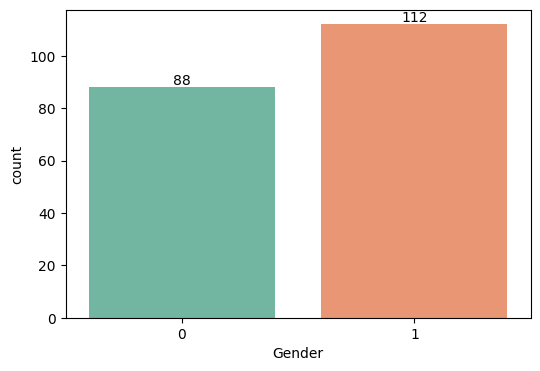

In [20]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x=df['Gender'], palette = 'Set2')

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        str(int(height)),
        ha='center',
        va='bottom'
    )

plt.show()

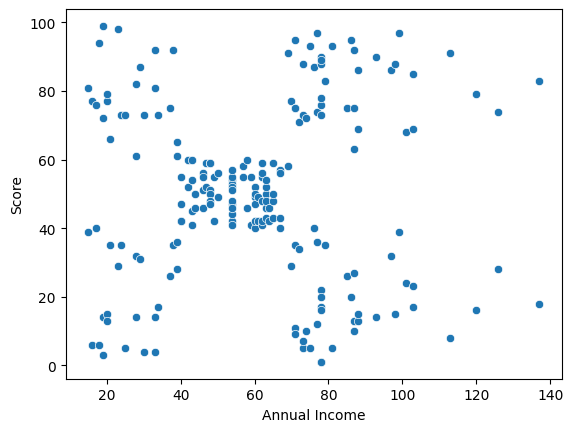

In [22]:
sns.scatterplot(x = df['Annual Income'], y = df['Score'])
plt.show()

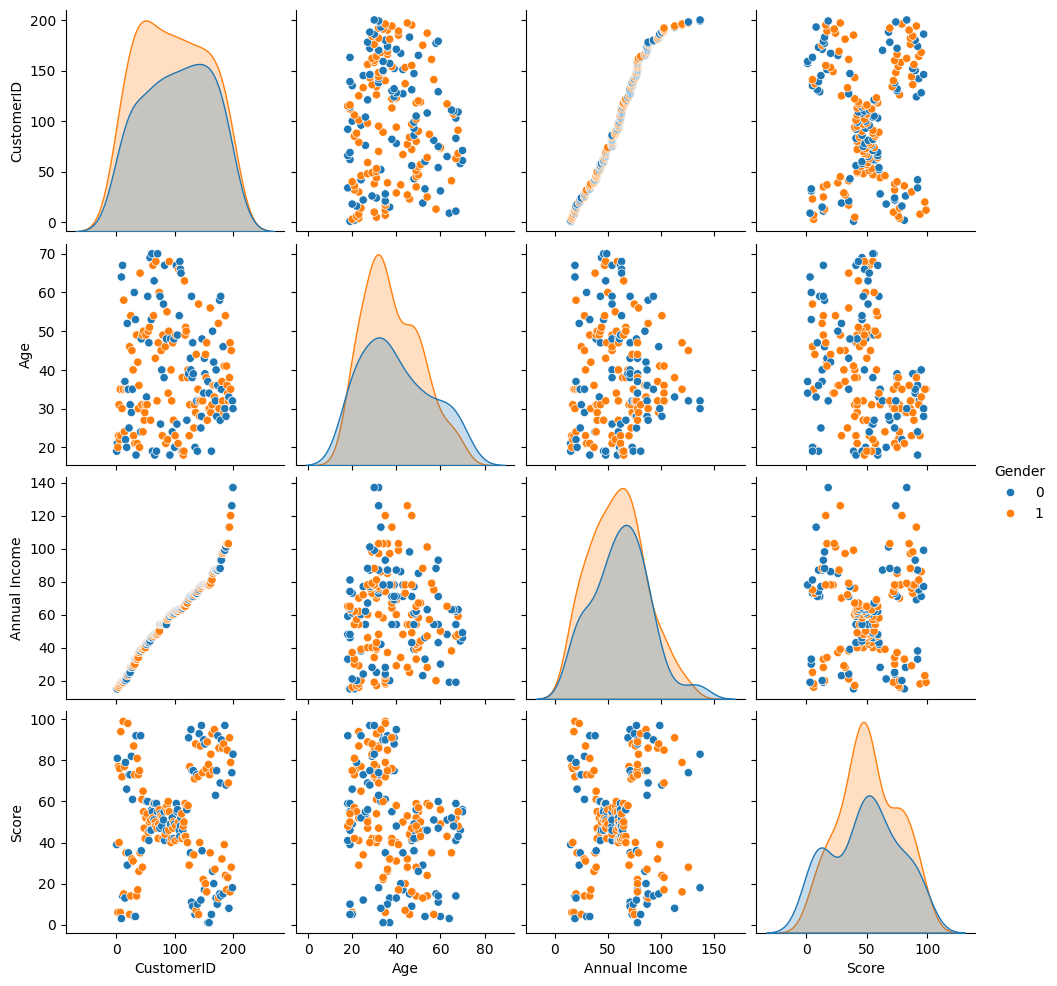

In [24]:
sns.pairplot(data=df, hue='Gender')
plt.show()

In [28]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=8)
km.fit(df[['Annual Income','Score']])

,n_clusters,8
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [29]:
pred = km.predict(df[['Annual Income','Score']])
pred

array([4, 3, 6, 3, 4, 3, 6, 3, 6, 3, 6, 3, 6, 3, 6, 3, 4, 3, 4, 3, 4, 3,
       6, 3, 6, 3, 4, 3, 4, 3, 6, 3, 6, 3, 6, 3, 6, 3, 4, 3, 4, 3, 4, 0,
       4, 0, 0, 0, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, 0, 0, 7, 7, 0, 0, 0, 0,
       0, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 5, 7, 5, 7, 5, 1, 5, 1, 5,
       7, 5, 1, 5, 1, 5, 1, 5, 1, 5, 7, 5, 1, 5, 7, 5, 1, 5, 1, 5, 1, 5,
       1, 5, 1, 5, 1, 5, 7, 5, 1, 5, 1, 5, 1, 5, 1, 5, 1, 5, 1, 5, 1, 5,
       1, 5, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2])

In [30]:
df['Initial Prediction'] = pred

In [31]:
df

,CustomerID,Gender,Age,Annual Income,Score,Initial Prediction
0,1,0,19,15,39,4
1,2,0,21,15,81,3
2,3,1,20,16,6,6
3,4,1,23,16,77,3
4,5,1,31,17,40,4
...,...,...,...,...,...,...
195,196,1,35,120,79,2
196,197,1,45,126,28,1
197,198,0,32,126,74,2
198,199,0,32,137,18,1


In [41]:
df1 = df[df['Initial Prediction'] == 1]
df2 = df[df['Initial Prediction'] == 2]
df3 = df[df['Initial Prediction'] == 3]
df4 = df[df['Initial Prediction'] == 4]
df5 = df[df['Initial Prediction'] == 5]
df6 = df[df['Initial Prediction'] == 6]
df7 = df[df['Initial Prediction'] == 7]

In [42]:
center = km.cluster_centers_
center

array([[ 48.1       ,  52.675     ],
       [ 89.40625   ,  15.59375   ],
       [108.18181818,  82.72727273],
       [ 25.0952381 ,  80.04761905],
       [ 30.        ,  34.61538462],
       [ 78.03571429,  81.89285714],
       [ 24.58333333,   9.58333333],
       [ 63.72093023,  46.1627907 ]])

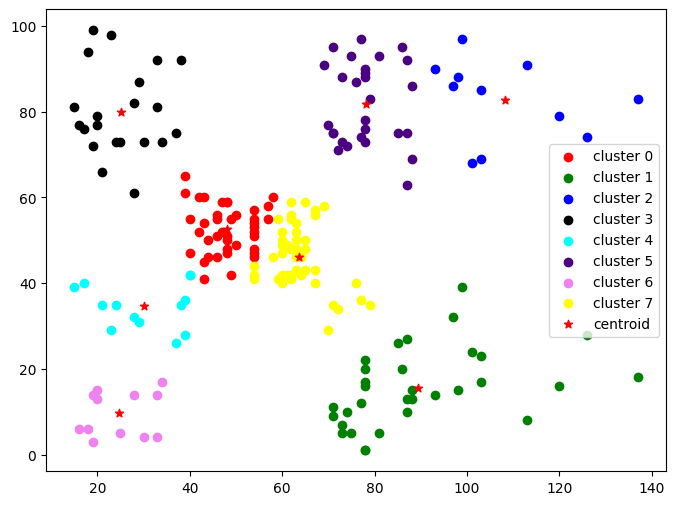

In [43]:
plt.figure(figsize=(8,6))
plt.scatter(df0['Annual Income'], df0.Score, color ="r", label = "cluster 0")
plt.scatter(df1['Annual Income'], df1.Score, color ="green", label = "cluster 1")
plt.scatter(df2['Annual Income'], df2.Score, color ="blue", label = "cluster 2")
plt.scatter(df3['Annual Income'], df3.Score, color ="black", label = "cluster 3")
plt.scatter(df4['Annual Income'], df4.Score, color ="cyan", label = "cluster 4")
plt.scatter(df5['Annual Income'], df5.Score, color ="indigo", label = "cluster 5")
plt.scatter(df6['Annual Income'], df6.Score, color ="violet", label = "cluster 6")
plt.scatter(df7['Annual Income'], df7.Score, color ="yellow", label = "cluster 7")

plt.scatter(center[:,0], center[:,1], color = "red", marker= "*", label = "centroid")
plt.legend()

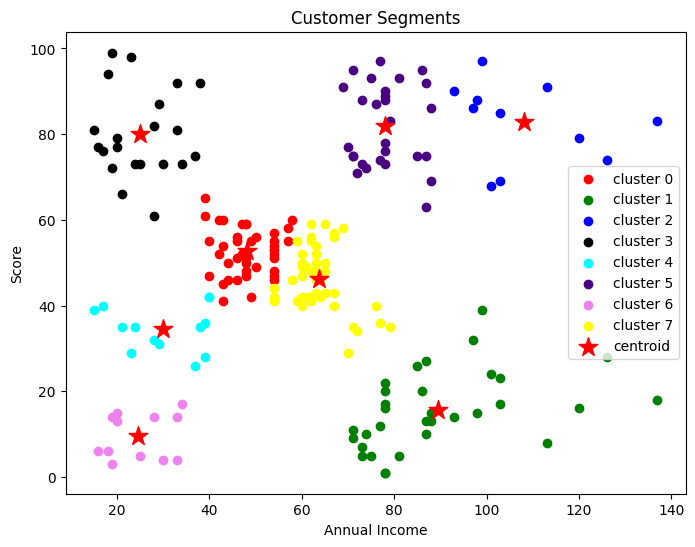

In [63]:
colors = ['r','green','blue','black','cyan','indigo','violet','yellow']
dfs = [df0, df1, df2, df3, df4, df5, df6, df7]

plt.figure(figsize=(8,6))

for i, df_cluster in enumerate(dfs):
    plt.scatter(
        df_cluster['Annual Income'],
        df_cluster['Score'],
        color=colors[i],
        label=f'cluster {i}'
    )

plt.scatter(center[:,0], center[:,1], color="red", marker="*", s=200, label="centroid")

plt.legend()
plt.xlabel('Annual Income')
plt.ylabel('Score')
plt.title('Customer Segments')
plt.show()

In [46]:
# elbow
wcss = []
clster= range(1,20)

for i in clster:
    km2 = KMeans(n_clusters=i)
    km2.fit(df[["Annual Income", "Score"]])
    wcss.append(km2.inertia_)

In [47]:
wcss

[269981.28,
 186362.95600651758,
 132162.13629759202,
 73880.64496247195,
 44448.45544793371,
 38797.9027638142,
 31969.426550235476,
 29452.690959303458,
 23402.85217103651,
 19829.031646581992,
 20047.99085884354,
 16566.70289397364,
 15269.328087156322,
 13466.44613821138,
 13336.973018106763,
 11253.835049485426,
 10515.645893237197,
 10100.92181917699,
 9446.570622372798]

Text(0.5, 0, 'Num of Clusters')

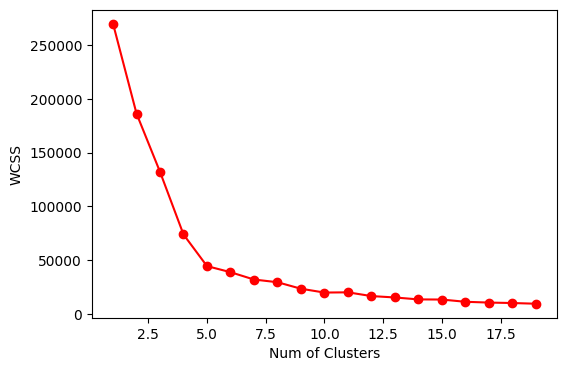

In [48]:
plt.figure(figsize=(6,4))
plt.plot(clster, wcss, marker = "o", color ="red")
plt.ylabel('WCSS')
plt.xlabel('Num of Clusters')

In [50]:
!pip install kneed


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
from kneed import KneeLocator
kn = KneeLocator(clster, wcss, curve= "convex", direction = "decreasing")

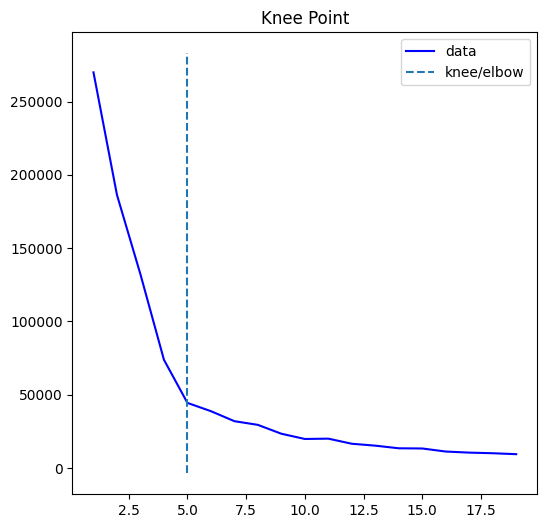

In [52]:
kn.plot_knee()

In [54]:
km3 = KMeans(n_clusters= 5)
pred = km3.fit_predict(df[["Annual Income", "Score"]])
pred

array([3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4,
       3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 0,
       3, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 0, 1, 2, 1, 2, 1,
       0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1])

In [55]:
df["new_pred"] = pred
df.head()

,CustomerID,Gender,Age,Annual Income,Score,Initial Prediction,new_pred
0,1,0,19,15,39,4,3
1,2,0,21,15,81,3,4
2,3,1,20,16,6,6,3
3,4,1,23,16,77,3,4
4,5,1,31,17,40,4,3


In [56]:
df["new_pred"].value_counts()

new_pred
0    81
1    39
2    35
3    23
4    22
Name: count, dtype: int64

In [57]:
df01 = df[df.new_pred == 0]
df11 = df[df.new_pred == 1]
df21= df[df.new_pred == 2]
df31= df[df.new_pred == 3]
df41= df[df.new_pred == 4]

In [58]:
cen2 = km3.cluster_centers_
cen2

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348],
       [25.72727273, 79.36363636]])

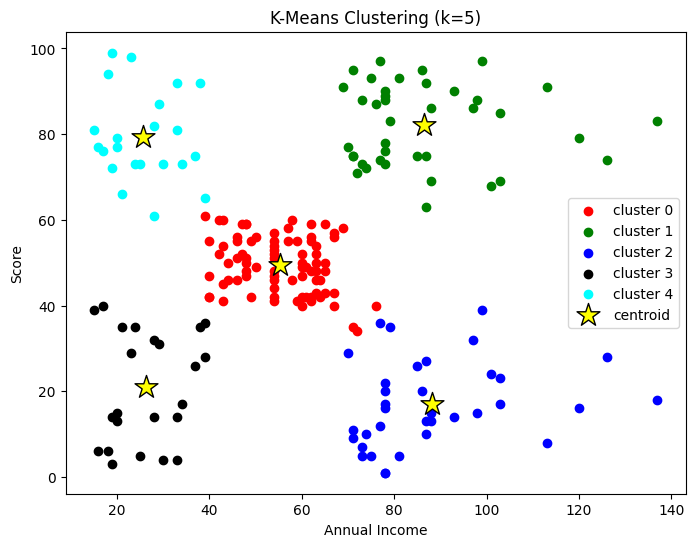

In [59]:
plt.figure(figsize=(8,6))

dfs = [df01, df11, df21, df31, df41]
colors = ['r','green','blue','black','cyan']

for i, df_cluster in enumerate(dfs):
    plt.scatter(
        df_cluster['Annual Income'],
        df_cluster['Score'],
        color=colors[i],
        label=f'cluster {i}'
    )

plt.scatter(cen2[:,0], cen2[:,1],
            color="yellow", marker="*", s=300,
            edgecolors="black", label="centroid")

plt.xlabel('Annual Income')
plt.ylabel('Score')
plt.title('K-Means Clustering (k=5)')
plt.legend()
plt.show()